In [1]:
import xarray as xr
import numpy as np
from scipy.ndimage import binary_erosion, binary_dilation
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
def coastal_band_mask(ds, var='u10', target_width_km=111):
    """
    Create a coastal band mask with uniform cross-shore width in km.
    """
    da = ds[var]
    if 'time' in da.dims:
        da = da.mean(dim='time')

    valid2d = np.isfinite(da).values.astype(bool)
    lat_vals = ds['lat'].values
    lon_vals = ds['lon'].values
    dlon = np.abs(lon_vals[1] - lon_vals[0])  # grid spacing in degrees

    # Find coastline (easternmost valid cell per row)
    band = np.zeros_like(valid2d, dtype=bool)

    for j in range(valid2d.shape[0]):
        row = valid2d[j, :]
        ocean_cols = np.where(row)[0]
        if len(ocean_cols) == 0:
            continue

        # Coast = easternmost valid cell
        i_coast = ocean_cols[-1]

        # How many cells = target_width_km at this latitude?
        A = 6371.0  # km
        dx_km = A * np.cos(np.deg2rad(lat_vals[j])) * np.deg2rad(dlon)
        n_cells = int(np.round(target_width_km / dx_km))

        # Fill n_cells westward from coast
        i_start = max(i_coast - n_cells, 0)
        band[j, i_start:i_coast + 1] = True

    # Only keep cells that are actually ocean
    band = band & valid2d

    da_mask = xr.DataArray(band, dims=('lat', 'lon'),
                           coords={'lat': ds['lat'], 'lon': ds['lon']})
    return da_mask

In [3]:
# # ============================================================
# # 1. Mask function (cross-shore dilation only)
# # ============================================================
# def coastal_band_mask(ds, var='u10', iterations=10):
#     da = ds[var]
#     if 'time' in da.dims:
#         da = da.mean(dim='time')
#     valid2d = np.isfinite(da).values.astype(bool)
#     eroded = binary_erosion(valid2d, structure=np.ones((3, 3)), iterations=1)
#     coast = valid2d & (~eroded)
#     cross_shore_kernel = np.array([[0, 0, 0],
#                                    [1, 1, 1],
#                                    [0, 0, 0]])
#     band = binary_dilation(coast, structure=cross_shore_kernel, iterations=iterations) & valid2d
#     da_mask = xr.DataArray(band, dims=('lat', 'lon'),
#                            coords={'lat': ds['lat'], 'lon': ds['lon']})
#     return da_mask

In [4]:
# # mask -- > this mask has equal spacing but different km resolution throughout due to the shelf 
# def coastal_band_mask(ds, var='u10', iterations=10):
#     """
#     Create a coastal band mask by dilating the coastline edge.

#     Parameters
#     ----------
#     ds : xr.Dataset
#         Must contain 2D lat/lon coords and the target variable.
#     var : str
#         Variable name used to detect land (NaN) vs ocean.
#     iterations : int
#         Number of dilation steps (~10 km per iteration on a ~10 km grid).

#     Returns
#     -------
#     da_mask : xr.DataArray
#         Boolean mask (True inside the coastal band).
#     """
#     valid2d = np.isfinite(ds[var].mean(dim='time')).values.astype(bool)

#     eroded = binary_erosion(valid2d, structure=np.ones((3, 3)), iterations=1)
#     coast = valid2d & (~eroded)

#     band = binary_dilation(coast, structure=np.ones((3, 3)), iterations=iterations) & valid2d

#     da_mask = xr.DataArray(
#         band,
#         dims=('lat', 'lon'),
#         coords={'lat': ds['lat'], 'lon': ds['lon']},
#     )
#     return da_mask

In [7]:
# ============================================================
# 2. Load data and apply mask
# ============================================================
ds = xr.open_dataset('winds_and_components.nc')
mask = coastal_band_mask(ds, var='Uek_geo', target_width_km=111)  # ~111 km cross-shore
wind_coastal = ds.where(mask).sel(lon=slice(-85, None), lat=slice(-20, -4))

In [8]:
# ============================================================
# 3. Find coastal and offshore boundary longitudes per latitude
# ============================================================
valid = np.isfinite(wind_coastal.Uek_geo.isel(time=0))
valid_e = valid.shift(lon=-1).fillna(False).astype(bool)
valid_w = valid.shift(lon=+1).fillna(False).astype(bool)

coast_mask = valid & (~valid_e)      # easternmost valid cell (coast)
offshore_mask = valid & (~valid_w)   # westernmost valid cell (offshore edge)

lat_all = wind_coastal.lat.values
lon_all = wind_coastal.lon.values

coast_lons = np.full(len(lat_all), np.nan)
offshore_lons = np.full(len(lat_all), np.nan)

for j in range(len(lat_all)):
    cols_e = np.where(coast_mask.isel(lat=j).values)[0]
    if len(cols_e) > 0:
        coast_lons[j] = lon_all[cols_e[0]]
    cols_w = np.where(offshore_mask.isel(lat=j).values)[0]
    if len(cols_w) > 0:
        offshore_lons[j] = lon_all[cols_w[0]]

In [9]:
# ============================================================
# 4. qdiv function — returns m²/s
# ============================================================
def qdiv_for_band(Uek, Vek,
                  lat_south, lat_north,
                  offshore_lons, coast_lons, all_lats):

    A = 6371000.0

    Uek_ = Uek.sel(lat=slice(lat_south, lat_north))
    Vek_ = Vek.sel(lat=slice(lat_south, lat_north))

    lat_vals = Uek_.lat.values
    lon_vals = Uek_.lon.values
    mean_lat = np.mean(lat_vals)

    # Alongshore length of this band (denominator for m³/s → m²/s)
    d_coast = A * np.deg2rad(np.abs(lat_vals[-1] - lat_vals[0]))

    # Build 2D strip mask following coast/offshore boundaries per row
    band_idx = np.where((all_lats >= lat_south) & (all_lats <= lat_north))[0]
    strip_mask = np.zeros((len(lat_vals), len(lon_vals)), dtype=bool)

    for j, idx in enumerate(band_idx):
        if j >= len(lat_vals):
            break
        lw = offshore_lons[idx]
        le = coast_lons[idx]
        if np.isfinite(lw) and np.isfinite(le):
            strip_mask[j, :] = (lon_vals >= lw) & (lon_vals <= le)

    # Apply strip mask
    strip_da = xr.DataArray(strip_mask, dims=('lat', 'lon'),
                            coords={'lat': lat_vals, 'lon': lon_vals})
    Uek_ = Uek_.where(strip_da)
    Vek_ = Vek_.where(strip_da)

    # Grid spacing for face integration
    dy_mean = A * np.deg2rad(np.abs(np.diff(lat_vals))).mean()
    dx_mean = A * np.cos(np.deg2rad(mean_lat)) * np.deg2rad(np.abs(np.diff(lon_vals))).mean()

    # Boundary detection
    valid_da = xr.where(np.isfinite(Uek_), 1, 0)
    valid_e = valid_da.shift(lon=-1)
    valid_w = valid_da.shift(lon=+1)
    west_mask = (valid_da == 1) & (valid_w == 0)
    east_mask = (valid_da == 1) & (valid_e == 0)

    easternmost  = Uek_.where(east_mask)
    westernmost  = Uek_.where(west_mask)
    southernmost = Vek_.isel(lat=0)
    northernmost = Vek_.isel(lat=-1)

    # Volume fluxes through each face (m³/s)
    QE = (easternmost.mean('lon')
          .rolling(lat=2, center=False)
          .mean(skipna=True).sum(dim='lat') * dy_mean)
    QW = -(westernmost.mean('lon')
           .rolling(lat=2, center=False)
           .mean(skipna=True).sum(dim='lat') * dy_mean)
    QN = (northernmost
          .rolling(lon=2, center=False)
          .mean(skipna=True).sum(dim='lon') * dx_mean)
    QS = -(southernmost
           .rolling(lon=2, center=False)
           .mean(skipna=True).sum(dim='lon') * dx_mean)

    # Normalize by alongshore length → m²/s
    Qdiv = (QW + QS + QN) / d_coast

    return Qdiv

In [10]:
def lat_band_mean(
    f,
    lat_top_start=-4,
    lat_top_end=-17,
):
    """
    Compute the mean of f for successive 1° latitude bands.

    Parameters
    ----------
    f : xarray.DataArray
        Must have a 'lat' dimension (and optionally time/lon/etc.).
    lat_top_start : float or int
        Northern latitude of the first band (e.g. -5).
    lat_top_end : float or int
        Northern latitude of the last band (e.g. -16).

    Returns
    -------
    f_band : xarray.DataArray
        Mean of f for each 1° band, with new dimension 'lat_band'.
        Any other original dimensions (e.g. time) are preserved.
    """

    results = []
    lat_band_centers = []

    for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
        lat_south = lat_north - 1

        # 1° band slice
        f_band = f.sel(lat=slice(lat_south, lat_north))

        # skip bands with no points
        if f_band.sizes.get("lat", 0) == 0:
            continue

        results.append(f_band.mean(dim='lat'))
        lat_band_centers.append(0.5 * (lat_south + lat_north))

    # concat over bands
    f_out = xr.concat(results, dim="lat_band")
    f_out = f_out.assign_coords(lat_band=np.array(lat_band_centers))

    return f_out

In [11]:
# ============================================================
# 5. Loop over latitude bands
# ============================================================
lat_top_start = -4
lat_top_end   = -17

results = []
lat_band_centers = []

for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
    lat_south = lat_north - 1
    Qdiv_band = qdiv_for_band(
        wind_coastal.Uek_geo, wind_coastal.Vek_geo,
        lat_south=lat_south, lat_north=lat_north,
        offshore_lons=offshore_lons, coast_lons=coast_lons,
        all_lats=lat_all,
    )
    results.append(Qdiv_band)
    lat_band_centers.append(0.5 * (lat_south + lat_north))

Qdiv_all = xr.concat(results, dim='lat_band')
U_ek = Qdiv_all.assign_coords(lat_band=lat_band_centers)

100%|████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 27.59it/s]


In [12]:
# This should show ~100 km difference per row
for j in range(len(lat_all)):
    if np.isfinite(coast_lons[j]) and np.isfinite(offshore_lons[j]):
        diff = np.abs(coast_lons[j] - offshore_lons[j])
        # if diff > 1.5:  # more than ~1.5 degrees = ~150 km
        print(f"lat={lat_all[j]:.1f}: coast={coast_lons[j]:.2f}, offshore={offshore_lons[j]:.2f}, diff={diff:.2f}°")

lat=-20.0: coast=-70.20, offshore=-71.28, diff=1.08°
lat=-19.9: coast=-70.20, offshore=-71.28, diff=1.08°
lat=-19.8: coast=-70.20, offshore=-71.28, diff=1.08°
lat=-19.8: coast=-70.20, offshore=-71.28, diff=1.08°
lat=-19.7: coast=-70.20, offshore=-71.28, diff=1.08°
lat=-19.6: coast=-70.28, offshore=-71.37, diff=1.08°
lat=-19.5: coast=-70.28, offshore=-71.37, diff=1.08°
lat=-19.4: coast=-70.28, offshore=-71.37, diff=1.08°
lat=-19.4: coast=-70.28, offshore=-71.37, diff=1.08°
lat=-19.3: coast=-70.28, offshore=-71.37, diff=1.08°
lat=-19.2: coast=-70.28, offshore=-71.37, diff=1.08°
lat=-19.1: coast=-70.28, offshore=-71.37, diff=1.08°
lat=-19.1: coast=-70.37, offshore=-71.45, diff=1.08°
lat=-19.0: coast=-70.37, offshore=-71.45, diff=1.08°
lat=-18.9: coast=-70.37, offshore=-71.45, diff=1.08°
lat=-18.8: coast=-70.37, offshore=-71.45, diff=1.08°
lat=-18.7: coast=-70.37, offshore=-71.45, diff=1.08°
lat=-18.7: coast=-70.37, offshore=-71.45, diff=1.08°
lat=-18.6: coast=-70.37, offshore=-71.45, diff

In [13]:
widths = []
A = 6371000.0
for j in range(len(lat_all)):
    if np.isfinite(coast_lons[j]) and np.isfinite(offshore_lons[j]):
        w = A * np.cos(np.deg2rad(lat_all[j])) * np.deg2rad(np.abs(coast_lons[j] - offshore_lons[j]))
        widths.append(w)
d_band = np.mean(widths)
print(f"Mean cross-shore width: {d_band/1000:.1f} km")

Mean cross-shore width: 110.3 km


In [14]:
A = 6371000.0
widths = np.full(len(lat_all), np.nan)
for j in range(len(lat_all)):
    if np.isfinite(coast_lons[j]) and np.isfinite(offshore_lons[j]):
        widths[j] = A * np.cos(np.deg2rad(lat_all[j])) * np.deg2rad(np.abs(coast_lons[j] - offshore_lons[j]))

widths_da = xr.DataArray(widths, dims='lat', coords={'lat': lat_all}, name='cross_shore_width')

d = lat_band_mean(widths_da, lat_top_start=-4, lat_top_end=-17)
print(d)

100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 3616.74it/s]

<xarray.DataArray 'cross_shore_width' (lat_band: 13)> Size: 104B
array([110845.23082605, 110675.6126214 , 110472.92003641, 110237.458738  ,
       109969.58189847, 109669.68891651, 109338.22398307, 108959.68046784,
       108548.44890858, 108122.884624  , 107648.20340893, 107142.84303382,
       110017.97519157])
Coordinates:
  * lat_band  (lat_band) float64 104B -4.5 -5.5 -6.5 -7.5 ... -14.5 -15.5 -16.5


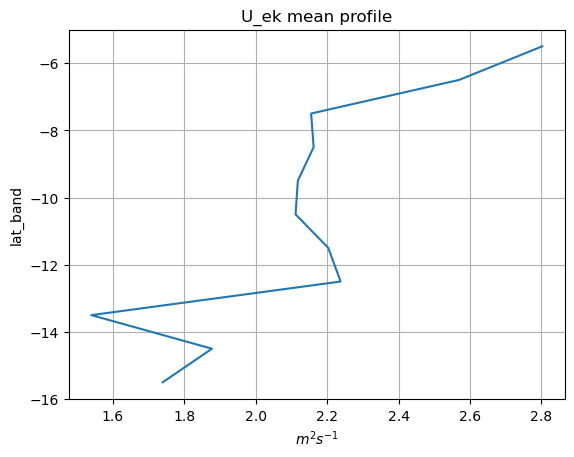

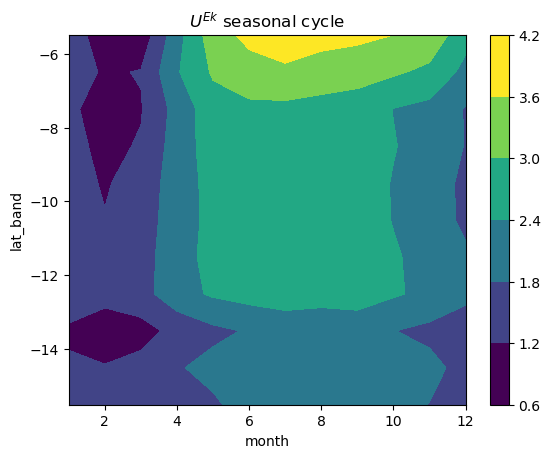

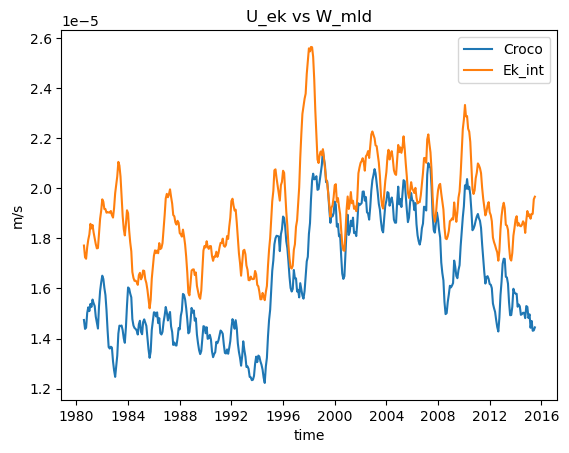

In [15]:
# ============================================================
# 6. Quick checks
# ============================================================

# Seasonality
def seasonality(data):
    return data.groupby('time.month').mean(dim='time')

# Latitudinal mean profile
U_ek.sel(lat_band=slice(-5, -16)).mean('time').rename('$m^{2}s^{-1}$').plot(y='lat_band')
plt.title('U_ek mean profile')
plt.grid(True)
plt.show()

# Seasonal Hovmöller
seasonality(U_ek).sel(lat_band=slice(-5, -16)).plot.contourf(x='month')
plt.title('$U^{Ek}$ seasonal cycle')
plt.show()

# Time series comparison with W_mld
wmld = xr.open_dataset('W_mld_Croco.nc').compute()
wmld = wmld.where(mask).sel(lon=slice(-85, None), lat=slice(-16, -5))

# d = (1/12) * 10 * 111 * 1000  # cross-shore width for m²/s → m/s conversion
# d= 111 * 1000

wmld.mean(dim=('lon', 'lat')).WMLD.rolling(time=13, center=True).mean().rename('m/s').plot(label='Croco')
(U_ek/d).mean(dim='lat_band').rolling(time=13, center=True).mean().rename('m/s').plot(label='Ek_int')
plt.legend()
plt.title('U_ek vs W_mld')
plt.show()

## Now the Geostrophic Velocity

$
u_{\mathrm{geo}} = \frac{g}{f}\,\frac{\Delta \mathrm{SSH}}{d_{\mathrm{coast}}}
$

$
\mathbf{U}_{\mathrm{geo}} = \mathbf{u}_{\mathrm{geo}} \times \mathrm{MLD}
$

In [16]:
ssh = xr.open_dataset('SSH.nc').compute()
ssh

<xarray.Dataset> Size: 564MB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
Data variables:
    SSH      (time, lat, lon) float32 564MB 0.212 0.212 0.2117 ... 0.0 0.0 0.0

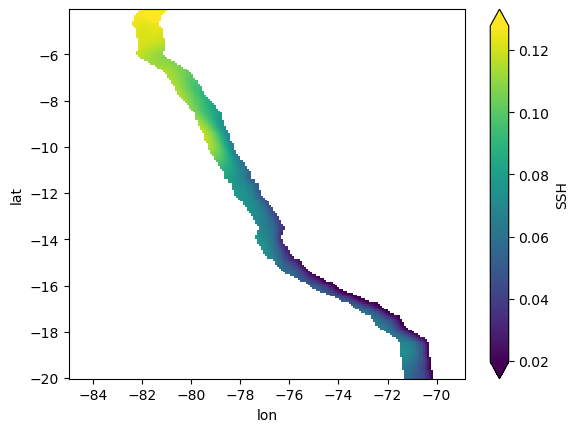

In [17]:
## SSH is in m
ssh = ssh.where(mask).sel(lon=slice(-85,None),lat=slice(-20,-4))
ssh.mean('time').SSH.plot(robust=True)

In [18]:
valid = np.isfinite(ssh.SSH.isel(time=0))
valid_e = valid.shift(lon=-1).fillna(False).astype(bool)
coast_mask = valid & (~valid_e)
ssh_coast = ssh.SSH.where(coast_mask)

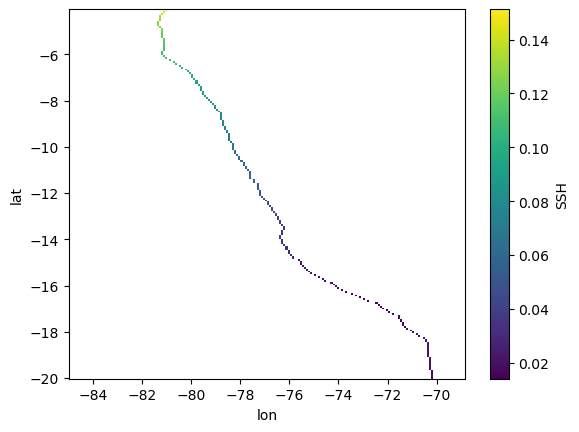

In [19]:
ssh_coast.mean('time').plot()

In [20]:
## Extract SSH at the coastline only (easternmost valid cell per row)
A = 6371000.0

lat_top_start = -4
lat_top_end   = -17

delta_SSH = []
d_coast_list = []

for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
    lat_south = lat_north - 1
    SSH_band = ssh_coast.mean('lon').sel(lat=slice(lat_south, lat_north))

    southernmost = SSH_band.isel(lat=0)
    northernmost = SSH_band.isel(lat=-1)

    delta_SSH.append(northernmost - southernmost)

    # Actual distance between south and north coastal points
    lat_s = SSH_band.lat.values[0]
    lat_n = SSH_band.lat.values[-1]
    d = A * np.deg2rad(np.abs(lat_n - lat_s))
    d_coast_list.append(d)

ssh_ = xr.concat(delta_SSH, dim='lat_band')
ssh_ = ssh_.assign_coords(
    lat_band=np.arange(lat_top_start - 0.5, lat_top_end - 0.5, -1)
)

d_coast = xr.DataArray(d_coast_list, dims='lat_band',
                        coords={'lat_band': ssh_.lat_band})

# Verify: should be positive on average (SSH increases northward along coast)
print("Mean ssh_ (should be positive):", ssh_.mean().values)

100%|████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 22.08it/s]

Mean ssh_ (should be positive): 0.009845316


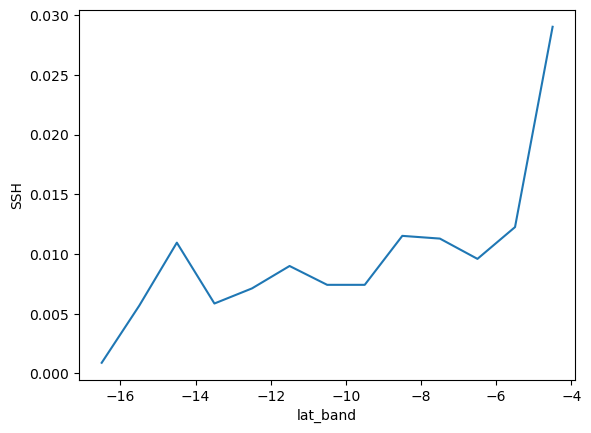

In [21]:
ssh_.mean('time').plot()

In [22]:
lat_centers = np.arange(lat_top_start - 0.5, lat_top_end - 0.5, -1)
Omega = 7.2921e-5
f_ = 2 * Omega * np.sin(np.deg2rad(lat_centers))
f_ = xr.DataArray(f_, dims='lat_band', coords={'lat_band': lat_centers})
f_

<xarray.DataArray (lat_band: 13)> Size: 104B
array([-1.14426314e-05, -1.39783362e-05, -1.65097831e-05, -1.90362009e-05,
       -2.15568201e-05, -2.40708729e-05, -2.65775935e-05, -2.90762183e-05,
       -3.15659862e-05, -3.40461388e-05, -3.65159206e-05, -3.89745792e-05,
       -4.14213659e-05])
Coordinates:
  * lat_band  (lat_band) float64 104B -4.5 -5.5 -6.5 -7.5 ... -14.5 -15.5 -16.5

In [23]:
# d_coast = (1/12)*10*111*1000  # 1 degree of latitude in meters
g = 9.81

# Geostrophic cross-shore velocity from alongshore SSH gradient at the coast.
# u_geo = (g/f) * (dSSH/dy)
# Sign convention for CUTI divergence framework:
#   In SH (f<0), with SSH increasing northward (ssh_>0):
#     u_geo = (g / f_neg) * (positive) = negative → onshore (convergent)
#   This is correct: onshore geostrophic return flow reduces CUTI below U_ek.
u_geo = (g / f_) * (ssh_ / d_coast)

# Verify: should be negative on average (onshore)
print("Mean u_geo (should be negative):", u_geo.mean().values)

Mean u_geo (should be negative): -0.05106895862698817


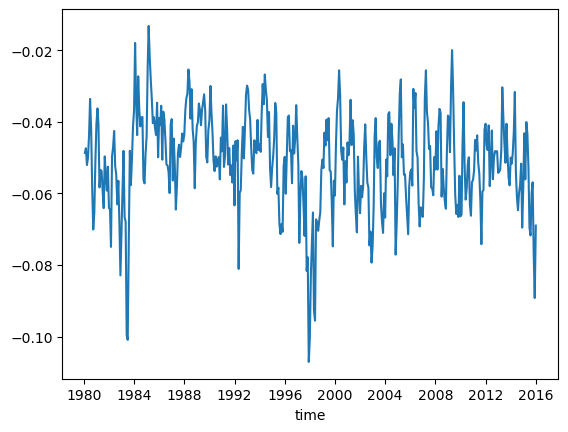

In [24]:
u_geo.mean(dim=('lat_band')).plot()

* The onshore geostrophic flow increased during EN 1997-98

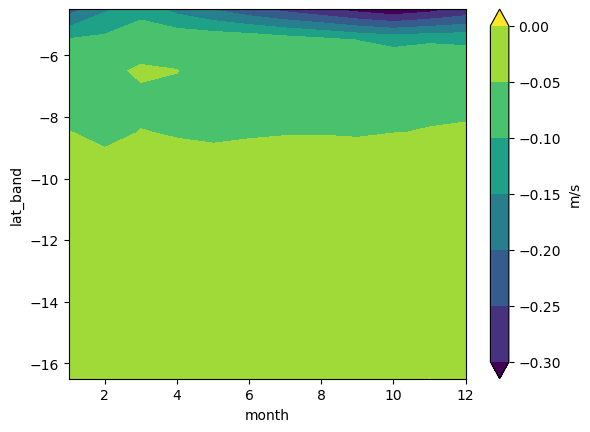

In [25]:
seasonality(u_geo.rename('m/s')).plot.contourf(robust=True)

### MLD

In [26]:
MLD_ds = xr.open_dataset('MLD.nc').compute()
MLD_ds

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    MLD      (time, lat, lon) float64 1GB 0.9402 0.9402 1.335 ... nan nan nan

In [27]:
mask_mld = coastal_band_mask(MLD_ds, var='MLD', target_width_km=111)
MLD_ds = MLD_ds.where(mask_mld).sel(lon=slice(-85,None),lat=slice(-20,-4))
MLD_ds

<xarray.Dataset> Size: 132MB
Dimensions:  (time: 432, lat: 197, lon: 194)
Coordinates:
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 2kB -19.99 -19.92 -19.84 ... -4.245 -4.162 -4.079
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    MLD      (time, lat, lon) float64 132MB nan nan nan nan ... nan nan nan nan

* Rossby radious in Peru goes from 150 to 50km, then the MLD should be around 100km, following first deformation Rossby radious criteria by Jacox(2018)

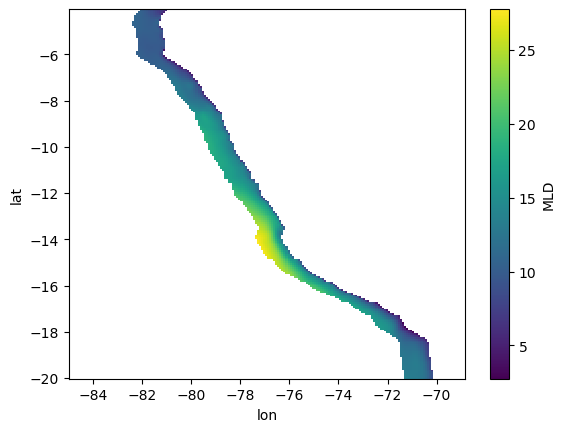

In [28]:
MLD_ds.MLD.std('time').plot()

In [29]:
delta_mld = []

lat_top_start = -4   # first northern edge
lat_top_end   = -17  # last northern edge

for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
    lat_south = lat_north - 1
    mld_band = MLD_ds.MLD.sel(lat=slice(lat_south, lat_north)).mean(dim='lat')
    delta_mld.append(mld_band)

mld_ = xr.concat(delta_mld, dim='lat_band')
mld_ = mld_.assign_coords(
    lat_band=np.arange(lat_top_start - 0.5, lat_top_end - 0.5, -1)
)

100%|███████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 239.40it/s]


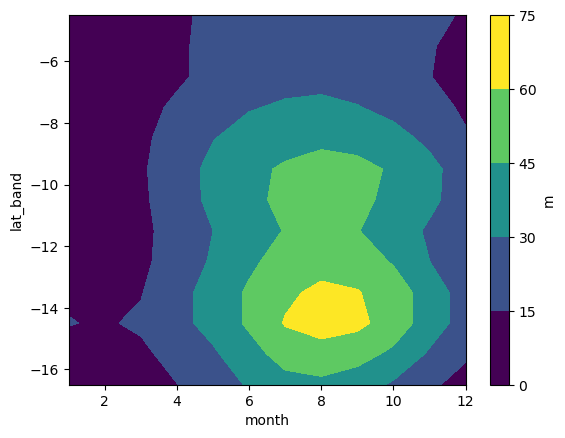

In [30]:
seasonality(mld_.mean(dim=('lon')).rename('m')).plot.contourf()

## $U^{geo}$

Text(0.5, 1.0, '$U^{Geo}$')

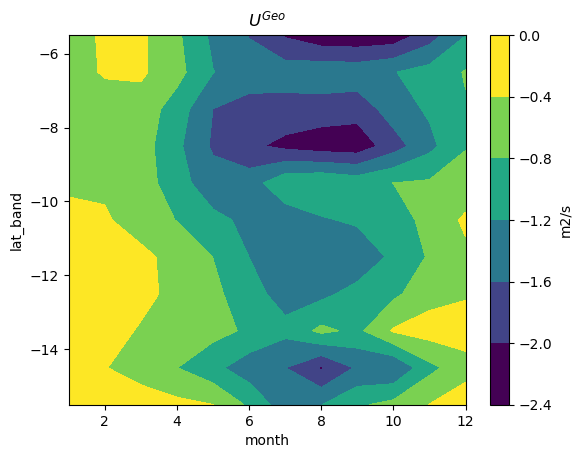

In [31]:
U_geo = (u_geo * mld_)
seasonality((u_geo * mld_).mean(dim='lon')).sel(lat_band=slice(-5,-16)).rename('m2/s').plot.contourf(robust=True)
# seasonality((u_geo * mld_).mean(dim='lon')).rename('m2/s').plot.contourf(robust=True)

plt.title('$U^{Geo}$')

* Negative is onshore 

In [32]:
U_geo.sel(lat_band=slice(-5.5,-16.5))

<xarray.DataArray (lat_band: 12, time: 432, lon: 194)> Size: 8MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * lat_band  (lat_band) float64 96B -5.5 -6.5 -7.5 -8.5 ... -14.5 -15.5 -16.5
  * time      (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon       (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87

## CUTI

$CUTI$ = $U^{Ek}$ + $U^{Geo}$

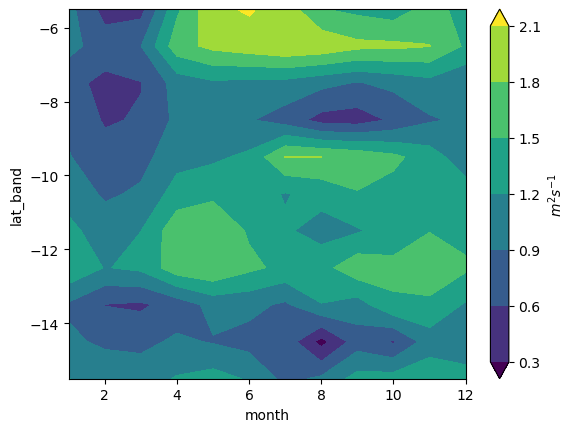

In [33]:
CUTI = (U_ek) + (U_geo)#m2/s

seasonality((CUTI).mean(dim='lon')).sel(lat_band=slice(-5,-16)).rename('$m^2s^{-1}$').plot.contourf(robust=True)

Text(0.5, 1.0, '$CUTI$')

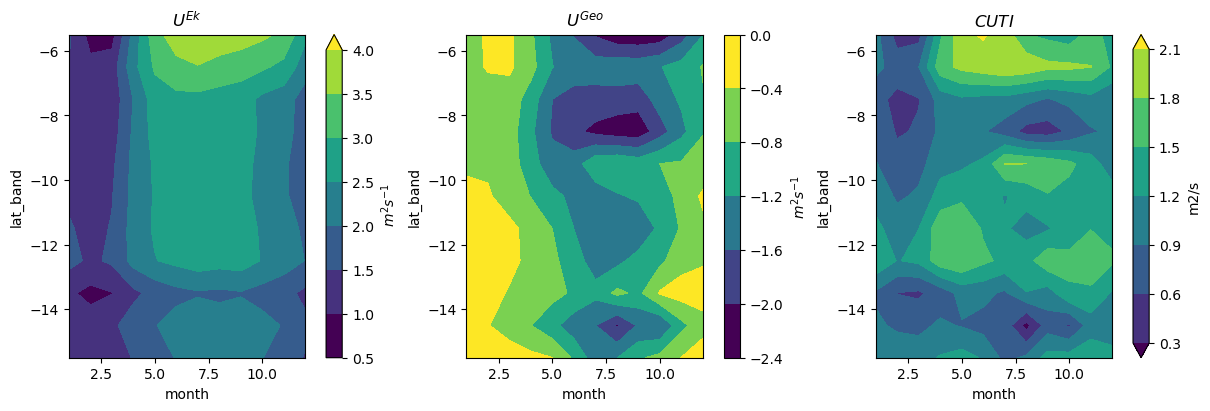

In [34]:
fig,ax = plt.subplots(1,3,figsize=(12,4),constrained_layout=True)

seasonality(U_ek).sel(lat_band=slice(-5,-16)).rename('$m^2s^{-1}$').plot.contourf(
    x='month',robust=True,ax=ax[0])
seasonality(U_geo).mean(dim='lon').sel(lat_band=slice(-5,-16)).rename('$m^2s^{-1}$').plot.contourf(
    x='month',robust=True,ax=ax[1])
seasonality((CUTI).mean(dim='lon')).sel(lat_band=slice(-5,-16)).rename('m2/s').plot.contourf(
    x='month',robust=True,ax=ax[2])

ax[0].set_title('$U^{Ek}$')
ax[1].set_title('$U^{Geo}$')
ax[2].set_title('$CUTI$')

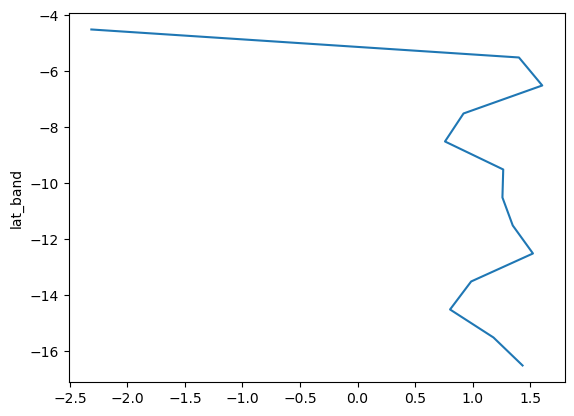

In [35]:
# (CUTI).mean(dim=('lon','time')).sel(lat_band=slice(-5,-16.5)).plot(y='lat_band')
(CUTI).mean(dim=('lon','time')).plot(y='lat_band')

In [36]:
wmld2 = xr.open_dataset('W_mld_Croco.nc').compute()
wmld2 = wmld2.where(mask).sel(lon=slice(-85,None),lat=slice(-17,-4))
wmld2

<xarray.Dataset> Size: 107MB
Dimensions:  (time: 432, lat: 159, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
Data variables:
    WMLD     (time, lat, lon) float64 107MB nan nan nan nan ... nan nan nan nan

In [37]:
wmld_ = lat_band_mean(wmld2.WMLD,
    lat_top_start=-4,
    lat_top_end=-17,
)

100%|███████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 239.62it/s]


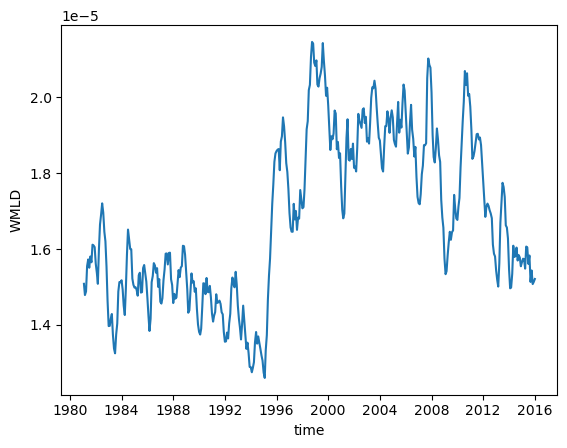

In [38]:
wmld_.sel(lat_band=slice(-5,-16)).mean(dim=('lat_band','lon')).rolling(time=13).mean().plot()

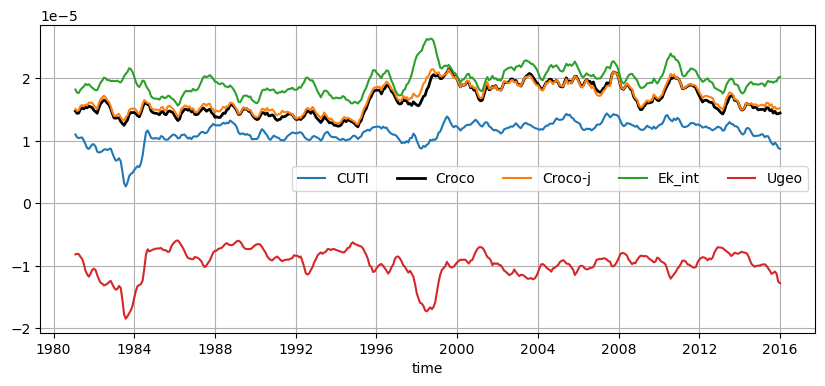

In [40]:
# d = (1/12)*10*111*1000
# d = d_coast.mean('lat_band')
# d = 111*1000

(CUTI/d).sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band')).rolling(time=13).mean().plot(label='CUTI',figsize=(10,4))
wmld.mean(dim=('lon','lat')).WMLD.rolling(time=13).mean().rename('m/s').plot(label='Croco',linewidth=2,color='black')
wmld_.sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band')).rolling(time=13).mean().rename('m/s').plot(label='Croco-j')

(((U_ek/d)).mean(dim='lat_band')).rolling(time=13).mean().rename('m/s').plot(label='Ek_int')
(U_geo/d).mean(dim=('lat_band','lon')).rolling(time=13).mean().plot(label='Ugeo')

plt.legend(ncols=6,loc='best')
plt.grid()

### Seasonality

In [41]:
wmld

<xarray.Dataset> Size: 90MB
Dimensions:  (time: 432, lat: 134, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
Data variables:
    WMLD     (time, lat, lon) float64 90MB nan nan nan nan ... nan nan nan nan

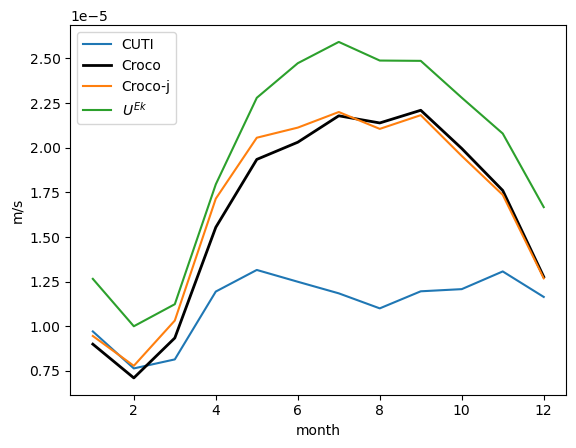

In [42]:
seasonality((CUTI/d)).sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band')).plot(label='CUTI')
seasonality(wmld).sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).WMLD.rename('m/s').plot(label='Croco',linewidth=2,color='black')
seasonality(wmld_.sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band'))).rename('m/s').plot(label='Croco-j')

(seasonality(U_ek/d)).mean(dim='lat_band').rename('m/s').plot(label='$U^{Ek}$')
# seasonality((U_geo/d).mean(dim=('lat_band','lon'))).plot(label='$U^{Geo}$')
# seasonality((ds.Uekman_Crossshore*-1/d).mean(dim=('lon','lat'))).plot(label='Uekman_crosshore')

plt.legend()

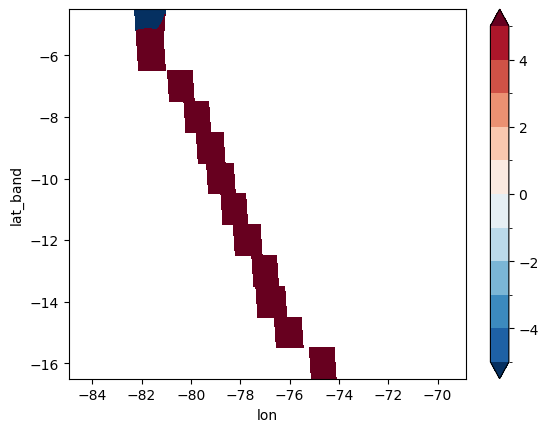

In [43]:
# (wmld*60*60*24).mean('time').WMLD.plot.contourf(robust=True,vmin=-5, vmax=5, cmap='RdBu_r',levels)
(CUTI*60*60*24).mean('time').plot.contourf(robust=True,vmin=-5, vmax=5, cmap='RdBu_r',levels=11)

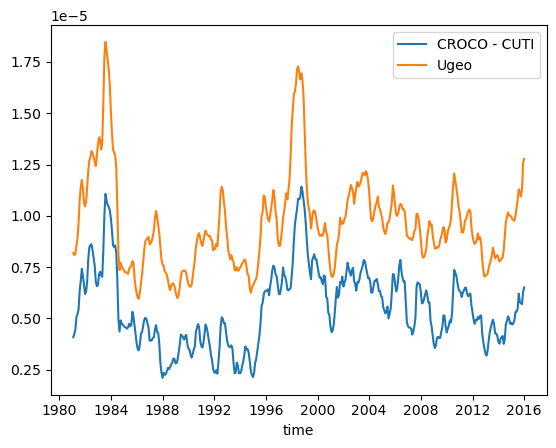

In [46]:
diff = wmld_.sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band')) - (CUTI/d).sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band'))

diff.rolling(time=13).mean().rename('m/s').plot(label='CROCO - CUTI')
(U_geo*-1/d).mean(dim=('lat_band','lon')).rolling(time=13).mean().plot(label='Ugeo')
plt.legend()

In [47]:
# Compute the ratio to quantify how much of U_GEO explains the offset
ratio = (diff.rolling(time=13).mean() / 
         (U_geo * -1/d).mean(dim=('lat_band','lon')).rolling(time=13).mean())

print(f"Mean ratio CROCO-CUTI / -Ugeo: {float(ratio.mean()):.2f}")

Mean ratio CROCO-CUTI / -Ugeo: 0.56


"Claude said: 
This means:

* 56% of $U^{GEO}$
UGEO is spatially non-uniform → has non-zero divergence → contributes to WMLDW_{MLD}

44% of $U^{GEO}$
is spatially uniform → zero divergence → does not contribute to WMLDW_{MLD}

This is actually a stronger result than I expected — it means the geostrophic flow in the NHUS is predominantly non-uniform spatially, which makes physical sense given the complex coastal geometry, varying shelf width, and mesoscale activity between 5°S and 16°S.
"